In [1]:
## visualize spots + pie plots of results 


import pickle


import scanpy as sc

import pandas as pd



import matplotlib.pyplot as plt
from matplotlib import colors
# color_map
# sc.settings.set_figure_params(dpi=120)

plt.rcParams['figure.figsize']=(8,8) #rescale figures
# sc.settings.verbosity = 3

sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)

# plt.rcParams["font.family"] = "Arial"
plt.rcParams['pdf.fonttype'] = 42




In [ ]:
import math 

def viz_slice_spots(adata_dict,celltype_classes,celltype_colors,legend=True):

    keys = list(adata_dict.keys())

    N = len(keys)
    n_rows = 2 
    n_cols = math.ceil((N) / n_rows)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 8 * n_rows))
    
    if hasattr(axs, "flatten"):
        axs = axs.flatten()
    else:
        axs = [axs]

    legend_handles = None
    for j, key in enumerate(keys):
        tmp = adata_dict[key].copy()
        # if ext_obs is not None:
        #     tmp.obs = ext_obs

    
        
        # check no extras
        assert set(tmp.obs.columns) == set(celltype_classes)

        # print(tmp.obs.columns)
        tmp.obs = tmp.obs[celltype_classes]  # reorder 
        # print(tmp.obs.columns)
        assert list(tmp.obs.columns) == celltype_classes # make sure order is correct 

        ax = axs[j]

        # print(key, tmp.obs.loc[str(0),].values, celltype_colors)

        # Plot each point as a pie chart
        for i in range(tmp.shape[0]):
            # Add a pie chart at each (x, y) position
            pie_size = 0.008  # Size of each pie chart
            wedges, _ = ax.pie(
                tmp.obs.loc[str(i),].values,
                center=(tmp.obsm['spatial'][i,0], tmp.obsm['spatial'][i,1]),
                radius=pie_size,colors=celltype_colors,
                wedgeprops={"linewidth": 0, "edgecolor": "none"} 
            )
            if legend_handles is None:
                legend_handles = wedges

        # Set axis limits
        mina = tmp.obsm['spatial'].min(axis=0)
        maxa = tmp.obsm['spatial'].max(axis=0)
        ax.set_xlim(mina[0], maxa[0])
        ax.set_ylim(mina[1]-0.06, maxa[1]+0.06)

        # Add labels and title
        #ax.set_xlabel("X-axis", fontsize=14)
        #ax.set_ylabel("Y-axis", fontsize=14)
        ax.set_title(key, fontsize=24)
        ax.set_aspect('equal')

    
    
    for ax in axs[N:]:
        ax.set_visible(False)

    

    if legend:
        fig.subplots_adjust(right=0.85)
        fig.legend(
            handles=legend_handles,
            labels=celltype_classes,
            title="CellTypes",
            loc="center left",
            bbox_to_anchor=(0.9, 0.5),
            fontsize=10,
            title_fontsize=20
        )

        # cbar = fig.colorbar(scatter, ax=scatter_ax, fraction=0.046, pad=0.04)
        # cbar.set_label("Sum of Cells per Spot", fontsize=12)



    # Adjust aspect ratio to ensure proper scaling
    #ax.set_aspect('equal')
    plt.tight_layout(rect = [0, 0, 0.85, 1])

    # Show the plot
    # plt.show()
    return fig

In [4]:
figdir = '../fig5_main/'
sc.settings.figdir = '../fig5_main/'

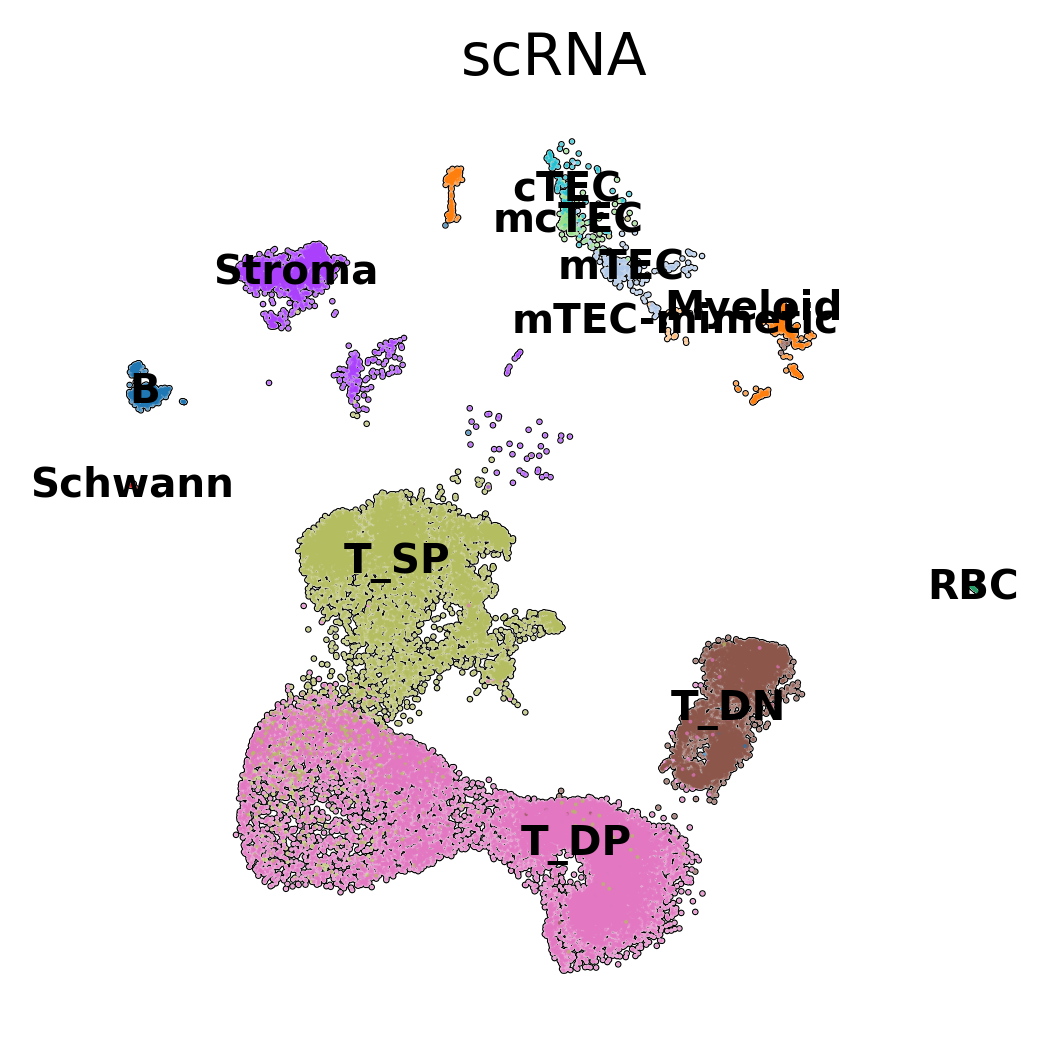

/tmp/ipykernel_3247309/2597451309.py:60: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  adata_spa = pickle.load(handle)
/tmp/ipykernel_3247309/2597451309.py:71: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that 

In [ ]:
spa_celltype_key='cell_type_level_0_episub'

dataset = '11'


# spa_celltype_key='celltype'


scrna_cluster_key = "cell_type_level_0_episub"
dataset_full = 'dataset11_thymus_curated_TECsubsets'
datasetdir = '../../datasets/' + dataset_full # 'dataset4_seqfishpluscai'
# adata_sc = sc.read(datasetdir + "/data/scrnaseq_raw.h5ad")
adata_sc = sc.read(datasetdir + "/data/scRNA_norm.h5ad")



sc.pl.umap(adata_sc, add_outline=True, legend_fontsize='x-small',frameon=False,legend_loc='on data', color=scrna_cluster_key,title='scRNA',save='_scRNAcelltypes.png')


cell_type = scrna_cluster_key
celltype_colors = list(adata_sc.uns[cell_type + '_colors'])
celltype_classes  = list(adata_sc.obs[cell_type].cat.categories)

simdir = datasetdir + '/results/simulations/pickles/'
basedir = datasetdir + '/results/simulations/slice_warps/'

# suffix = '_norm1knolog'

numeta = len(celltype_classes)



# N = 50
# nneigh = 10
# nbdswaps = 2
par_lambda = 0.1
par_bw = 0.01
augment = True
gt_align = False
kernel3d_bw_slices = 8
bandwidth = 0.01 
num_augment = 20
anno_name = scrna_cluster_key

adata_spa_path = '../../datasets/' + dataset_full + '/data/spatial_norm.pickle' # simdir + 'multi_slice_simulated_' + 'sptsz_' + str(N)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nbdswaps) + suffix + '.pickle' # '_old.pickle'

# key_name = 'linear_0'

result_metric = ['orig_rmse',   'avg_corr_pe','avg_jsd']

# ground truth 
with open(adata_spa_path, 'rb') as handle:
    adata_spa = pickle.load(handle)



mode = 'multislice'
mode_nbd = 'variabletranscr'
aligntool = 'moscot'
# partesting = '_partesting_parlambda_' + str(par_lambda) + '_parbw_' + str(par_bw) + '_' + 'nbdtype_' + mode_nbd + '_realalign_' + aligntool
partesting =  '_partesting_' + 'parlambda_' + str(par_lambda) + '_parbw_' + str(bandwidth) + '_nbdtype_' + mode_nbd + '_gtalign_' + str(gt_align) + '_augment_' + str(augment) + '_kernel3d_bw_slices_' + str(kernel3d_bw_slices) + '_num_augment_' + str(num_augment) + '_anno_' + anno_name + aligntool # + '_pareta1_' + str(par_eta1) +  '_3Dkernelbw_' + str(kernel3d_bw_slices_curr)
res_file = 'deconv_' + mode + '_' + mode_nbd  + partesting + '_sc.pickle' 
with open(basedir + res_file, 'rb') as handle:
    deconv_ms = pickle.load(handle)



## Tangram-sc
res_file = 'deconv_st1_' + 'anno_type_' + spa_celltype_key  + '_tangramsc.pickle'
with open(basedir + res_file, 'rb') as handle:
    deconv_tangramsc= pickle.load(handle)
# deconv_tangramsc = deconv_tangramsc['linear_0']


## Tangram-bulk
res_file = 'deconv_st1_' + 'anno_type_' + spa_celltype_key  + '_tangram.pickle'
with open(basedir + res_file, 'rb') as handle:
    deconv_tangram = pickle.load(handle)
# deconv_tangram = deconv_tangram['linear_0']
# Cell2location
res_file = 'deconv_st1_' + 'anno_type_' + spa_celltype_key  + '_cell2location.pickle'
with open(basedir + res_file, 'rb') as handle:
    deconv_cell2loc = pickle.load(handle)
# deconv_cell2loc = deconv_cell2loc['linear_0']
## CARD 
# res_file = 'deconv_st1_' + 'anno_type_' + spa_celltype_key  + '_CARD.pickle'
# with open(basedir + res_file, 'rb') as handle:
#     deconv_card = pickle.load(handle)
# deconv_card = deconv_card['linear_0']



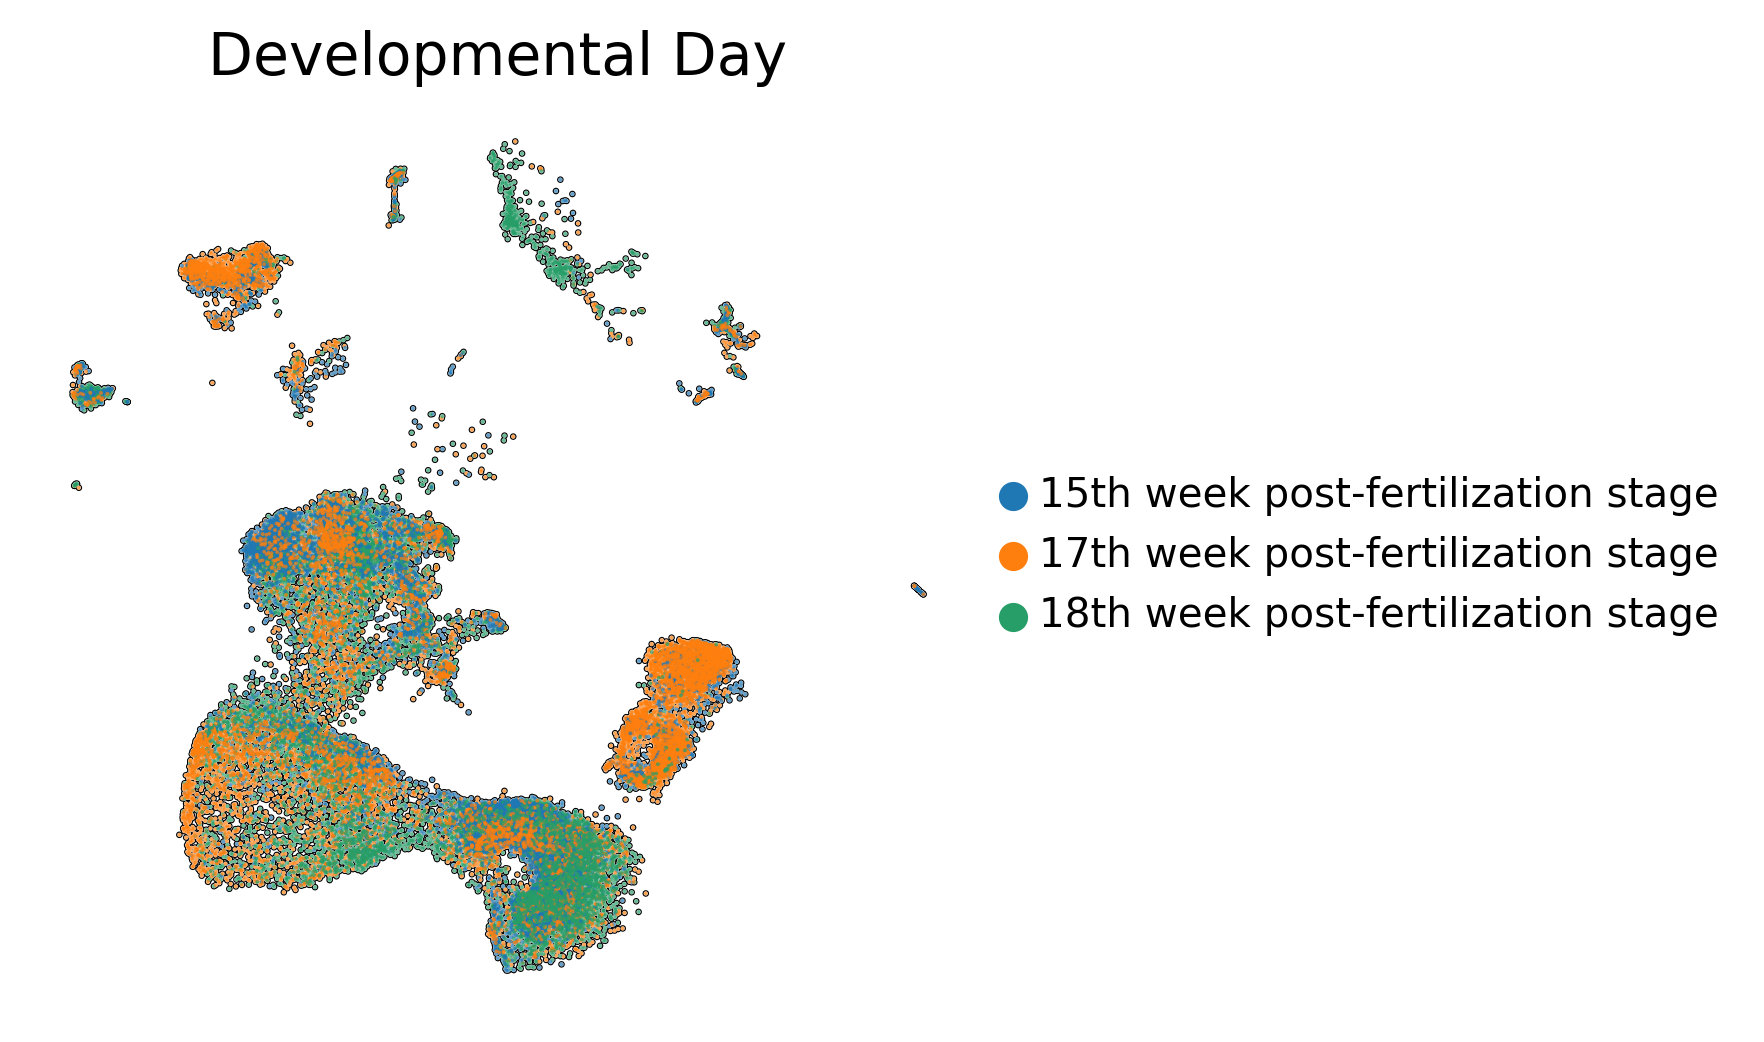

In [5]:
# development_stage
sc.pl.umap(adata_sc, add_outline=True, legend_fontsize='x-small',frameon=False,color='development_stage',title='Developmental Day',save='_timept.png')


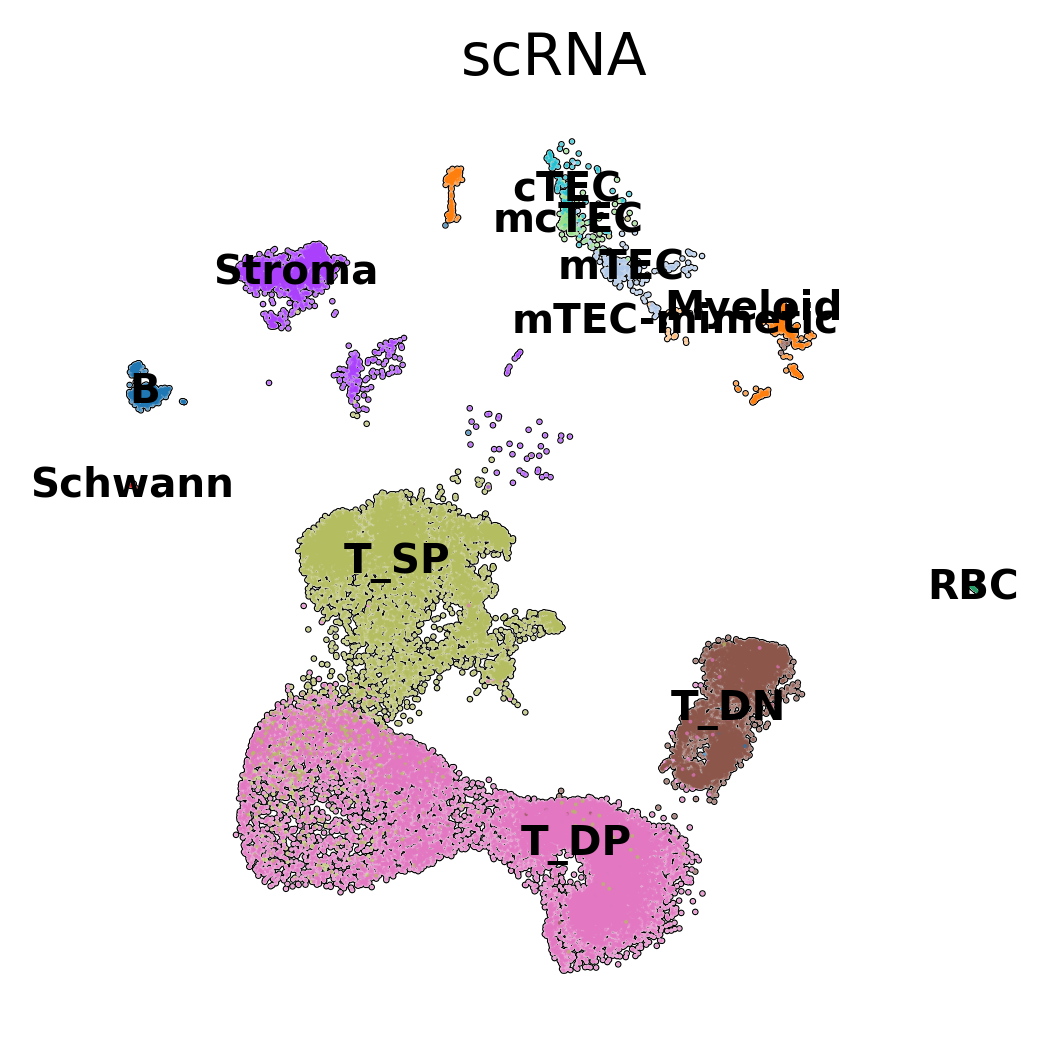

In [6]:
sc.pl.umap(adata_sc, add_outline=True, legend_fontsize='x-small',frameon=False,legend_loc='on data', color=scrna_cluster_key,title='scRNA',save='_scRNAcelltypes.pdf')


In [7]:


all_algos =  {'GroundTruth':adata_spa,

              'SpaDecoder':deconv_ms,

              'Tangramsc':deconv_tangramsc,
              'Tangrambulk':deconv_tangram,
               'Cell2location':deconv_cell2loc}
             #  'CARD':deconv_card}




## plot deconv one by one 

In [8]:

def viz_slice_spots_one(adata, celltype_classes, celltype_colors, legend=True):
    # Ensure that the required celltype columns exist in adata.obs
    

    # fig, axs = plt.subplots(1, 1, figsize=(20, 18))

    # if hasattr(axs, "flatten"):
    #     axs = axs.flatten()
    # else:
    #     axs = [axs]

    # Reorder the cell types in adata.obs
    legend_handles = None
    assert set(adata.obs.columns) == set(celltype_classes)
    adata.obs = adata.obs[celltype_classes]
    assert list(adata.obs.columns) == celltype_classes
    # ax = axs[j]
    

    # Create a plot with subplots
    N = 1  # Only one object, so N = 1
    n_rows = 1
    n_cols = 1
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 16))


    
    # Plot each point as a pie chart for the single Scanpy object (adata)
    for i in range(adata.obs.shape[0]):
        # Add a pie chart at each (x, y) position
        pie_size = 0.008  # Size of each pie chart
        cell_name = adata.obs.index[i]
        wedges, _ = ax.pie(
            adata.obs.loc[cell_name,].values,
            center=(adata.obsm['spatial'][i, 0], adata.obsm['spatial'][i, 1]),
            radius=pie_size, colors=celltype_colors,
            wedgeprops={"linewidth": 0, "edgecolor": "none"}
        )

    # Set axis limits based on spatial data
    mina = adata.obsm['spatial'].min(axis=0)
    maxa = adata.obsm['spatial'].max(axis=0)
    ax.set_xlim(mina[0], maxa[0])
    ax.set_ylim(mina[1] - 0.06, maxa[1] + 0.06)

    # Add title and other settings
    ax.set_title("Tissue Slice Visualization", fontsize=24)
    ax.set_aspect('equal')

    if legend:
        fig.subplots_adjust(right=0.85)
        fig.legend(
            handles=wedges,
            labels=celltype_classes,
            title="CellTypes",
            loc="center left",
            bbox_to_anchor=(0.9, 0.5),
            fontsize=10,
            title_fontsize=20
        )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    return fig



In [10]:




from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

dataset = '11'
# output_pdf = "./figures/viz_slices_deconv_output_dataset_" + dataset + "_individuals.pdf"


# with PdfPages(output_pdf) as pdf:

for realidx in deconv_ms.keys(): # real slice 
    # for simidx in [0]:#metrics_card['linear_0'][realidx].keys(): # sim slice 
    adata_dict = {}
    for algo_name in all_algos.keys():
        if algo_name != 'GroundTruth':
            adata_dict[algo_name + 'Sample:' + str(realidx) ] = all_algos['GroundTruth'][realidx].copy()
            if algo_name not in ['CARD','Cell2location']:
                adata_dict[algo_name + 'Sample:' + str(realidx) ].obs = all_algos[algo_name][realidx][0].T
            else:
                adata_dict[algo_name + 'Sample:' + str(realidx) ].obs = all_algos[algo_name][realidx].T
        else:
            continue 
            # adata_dict[algo_name + 'Sample:' + str(realidx) ] = all_algos['GroundTruth'][realidx].copy()
            # adata_dict[algo_name + 'Sample:' + str(realidx) ].obs = adata_dict[algo_name + 'Sample:' + str(realidx) ].obs[['cell_type']].copy()

            # print(adata_dict[algo_name + 'Sample:' + str(realidx) + 'Sim:' + str(simidx)])
        fig = viz_slice_spots_one(adata_dict[algo_name + 'Sample:' + str(realidx) ],celltype_classes,celltype_colors,legend=True)

        fig_path = figdir + "/viz_slices_deconv_output_dataset_" + dataset + "_algo_" + algo_name + "_realslice_" + str(realidx)  + "_individuals.pdf"
        fig.savefig(fig_path, dpi=1200, bbox_inches='tight')
        plt.close(fig)

                

In [ ]:
slicelist = []

for entry in ['16thpcw', '17thpcw', '18thpcw', '19thpcw']:
    adata_tmp = adata_spa[entry].copy()
    adata_tmp.obs = deconv_ms[entry][0].T

    for entry2 in ['Stroma','T_DN','T_DP','T_SP','cTEC','mTEC']:
        sc.pl.embedding(adata_tmp,basis='spatial',legend_loc=None, frameon=False,  color=entry2, vmin=adata_tmp.obs.min().min(), vmax=adata_tmp.obs.max().max(), size=20, cmap='managua_r', save='_slice_' + entry + '_celltype_' + entry2 + '_slice_prop.pdf')#v2.png') 

In [7]:
ctypes = set()
for entry in adata_spa.keys():
    print(adata_spa[entry].uns['cell_type_colors'])
    ctypes = ctypes.union(set(adata_spa[entry].obs['cell_type'].cat.categories))
    # sc.pl.embedding(adata_spa[entry], 'spatial',size=20, color='cell_type')

['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#aa40fc' '#8c564b']
['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#aa40fc' '#8c564b' '#e377c2']
['#1f77b4' '#ff7f0e' '#279e68']
['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#aa40fc' '#8c564b' '#e377c2']


In [8]:
ctypes = list(ctypes)
ctypes

['B cell',
 'Schwann cell',
 'T cell',
 'fibroblast',
 'dendritic cell',
 'smooth muscle cell',
 'granulocyte monocyte progenitor cell',
 'pericyte',
 'endothelial cell',
 'macrophage',
 'epithelial cell']

In [9]:
ctype_pastel_colors = [
    # "blu",  # Pastel Red
    # "#FFDFBA",  # Pastel Orange
    # "#FFFFBA",  # Pastel Yellow
    # "#BAFFC9",  # Pastel Green
    # "#BAE1FF",  # Pastel Blue
    # "#D5BAFF",  # Pastel Purple
    # "#FFBAD6",  # Pastel Pink
    # "#C2F0FC",  # Pastel Cyan
    # "#FCE2BA",  # Pastel Peach
    # "#E0BAFC",  # Pastel Lavender
    # "#B2EBF2",  # Pastel Aqua

    '#1f77b4', 
    '#ff7f0e',
      '#279e68',
        '#d62728',
          '#aa40fc',
            '#8c564b',
            '#e377c2',
              '#17becf',  # Cyan
    '#bcbd22',  # Olive
      '#8c6d31',  # Tan
   #  '#8dd3c7',  # Mint
    '#fb8072',  # Salmon

]

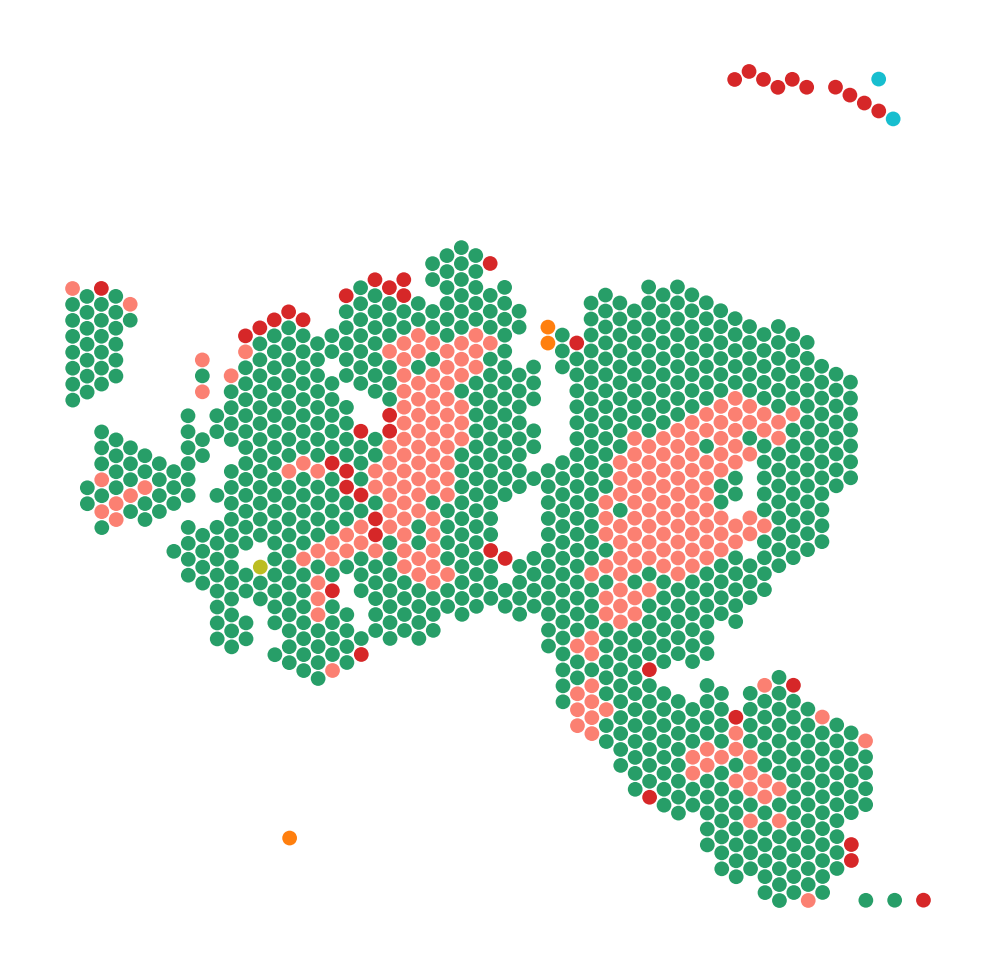

In [ ]:
# ctypes = set()
for entry in adata_spa.keys():
    # print(adata_spa[entry].uns['cell_type_colors'])
    # ctypes = ctypes.union(set(adata_spa[entry].obs['cell_type'].cat.categories))
    tmp_colors = []
    for entry2 in adata_spa[entry].obs['cell_type'].cat.categories:
        tmp_colors.append(ctype_pastel_colors[ctypes.index(entry2)])
    adata_spa[entry].uns['cell_type_colors'] = tmp_colors

    sc.pl.embedding(adata_spa[entry], 'spatial',size=50, color='cell_type', frameon=False, legend_loc=None, title='',  save='_GT_celltypes_' + entry + '_no_legend.pdf')